Question 6<br>
Section (a) - Finding partial derivations of Goussian function $G(x, y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$ <br>$\frac{\partial G}{\partial x} = -\frac{x}{\sigma^2} \cdot G(x, y)$ and $\frac{\partial G}{\partial y} = -\frac{y}{\sigma^2} \cdot G(x, y)$


In [1]:
import sympy as sp

# Define symbols
x, y, sigma = sp.symbols('x y sigma')

G = (1/(2*sp.pi*sigma**2)) * sp.exp(-(x**2 + y**2)/(2*sigma**2))

# Differentiation
Gx = sp.diff(G,x)
Gy = sp.diff(G,y)

Gx_byG = sp.simplify(Gx / G) 
Gy_byG = sp.simplify(Gy / G)

print("dG/dx =", f'{Gx_byG} * G')
print("dG/dy =", f'{Gy_byG} * G')

dG/dx = -x/sigma**2 * G
dG/dy = -y/sigma**2 * G


Secction (b) - Normalised $5\times5$ Gaussian Kernal for derivative of Gaussian filter

In [2]:
import numpy as np

x = np.arange(-2,3)
y = np.arange(-2,3)

X, Y = np.meshgrid(x,y)

# Gaussian
sigma = 2
G = (1 / (2 * np.pi * sigma**2)) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))

# Derivatives
dG_dx = -(X / sigma**2) * G
dG_dy = -(Y / sigma**2) * G

# Normalization
dG_dx = dG_dx / np.sum(np.abs(dG_dx))
dG_dy = dG_dy / np.sum(np.abs(dG_dy))

print("dG/dx kernel:\n", dG_dx)
print("\ndG/dy kernel:\n", dG_dy)

dG/dx kernel:
 [[ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.07275825  0.05293131 -0.         -0.05293131 -0.07275825]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]]

dG/dy kernel:
 [[ 0.04413011  0.06420893  0.07275825  0.06420893  0.04413011]
 [ 0.03210446  0.04671172  0.05293131  0.04671172  0.03210446]
 [-0.         -0.         -0.         -0.         -0.        ]
 [-0.03210446 -0.04671172 -0.05293131 -0.04671172 -0.03210446]
 [-0.04413011 -0.06420893 -0.07275825 -0.06420893 -0.04413011]]


Secction (c) - 3D plot of kernel

Text(0.5, 0, 'Kernel Value')

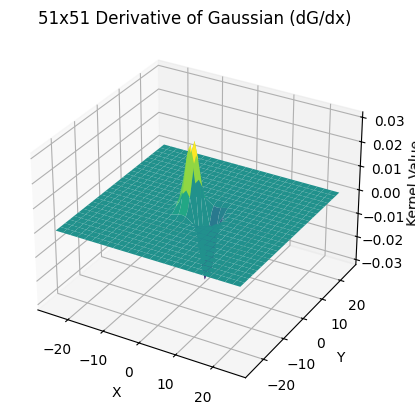

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-25,26)
y = np.arange(-25,26)

X, Y = np.meshgrid(x,y)

# Gaussian
sigma = 2
G = (1 / (2 * np.pi * sigma**2)) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))

# Derivatives
dG_dx = -(X / sigma**2) * G

# Normalization
dG_dx = dG_dx / np.sum(np.abs(dG_dx))

# Visualize
fig = plt.figure()
ax = fig.add_subplot(1,1,1,projection='3d')
ax.plot_surface(X,Y,dG_dx,cmap='viridis')

ax.set_title("51x51 Derivative of Gaussian (dG/dx)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Kernel Value")


Section (d) - Applying Kernel to an Image

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

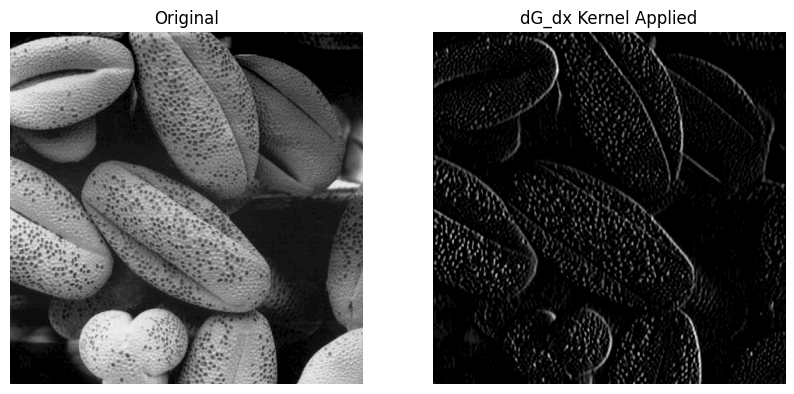

In [12]:
import cv2 as cv

img = cv.imread('shells.tif')
if img is None:
    print("Could not read input image")
    sys.exit(1)

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

x = np.arange(-2,3)
y = np.arange(-2,3)

X, Y = np.meshgrid(x,y)

# Gaussian
sigma = 2
G = (1 / (2 * np.pi * sigma**2)) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))

# Derivatives
dG_dx = -(X / sigma**2) * G
dG_dy = -(Y / sigma**2) * G

# Normalization
dG_dx = dG_dx / np.sum(np.abs(dG_dx))
dG_dy = dG_dy / np.sum(np.abs(dG_dy))

# Apply kernel
img_conv = cv.filter2D(img_gray, -1, dG_dx)
img_final = np.clip(img_conv, 0, 255).astype(np.uint8)

plot, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(img_gray,cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(img_final,cmap='gray')
ax[1].set_title('dG_dx Kernel Applied')
ax[1].axis('off')

Section (e) - Applying Open CV Soble

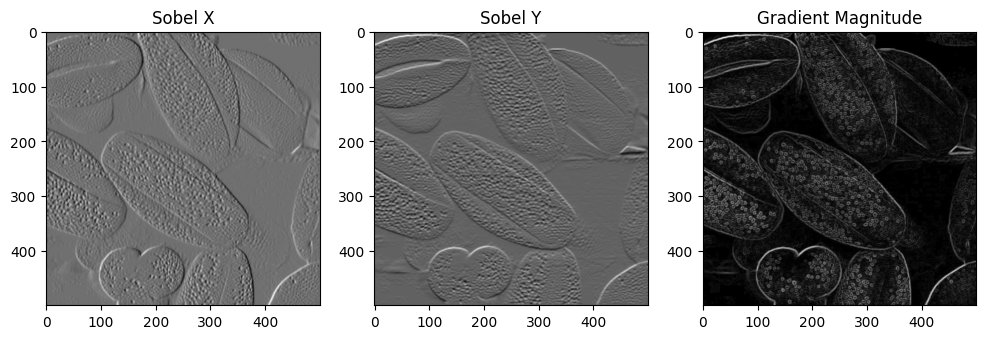

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Read image (grayscale)
img = cv.imread('shells.tif', cv.IMREAD_GRAYSCALE)

# Compute gradients
sobel_x = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=5)
sobel_y = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=5)

# Gradient magnitude (optional)
magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

# Display
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Sobel X")
plt.imshow(sobel_x, cmap='gray')

plt.subplot(1,3,2)
plt.title("Sobel Y")
plt.imshow(sobel_y, cmap='gray')

plt.subplot(1,3,3)
plt.title("Gradient Magnitude")
plt.imshow(magnitude, cmap='gray')

plt.show()